# AD Campaign Performance Prediction 

## Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Step 2: Load Dataset

In [3]:
campaign_sales = pd.read_csv('products_campaign_sales.csv')
print('Shape:', campaign_sales.shape)
campaign_sales.head()

Shape: (731, 11)


,limit_infor,campaign_type,campaign_level,product_level,resource_amount,email_rate,price,discount_rate,hour_resouces,campaign_fee,orders
0,0,6,0,1,1,0.08,140.0,0.83,93,888,1981
1,0,0,0,1,1,0.10,144.0,0.75,150,836,986
2,0,1,1,1,1,0.12,149.0,0.84,86,1330,1416
3,0,3,1,2,1,0.12,141.0,0.82,95,2273,2368
4,0,0,0,1,1,0.10,146.0,0.59,73,1456,1529


In [4]:
campaign_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   limit_infor      731 non-null    int64  
 1   campaign_type    731 non-null    int64  
 2   campaign_level   731 non-null    int64  
 3   product_level    731 non-null    int64  
 4   resource_amount  731 non-null    int64  
 5   email_rate       731 non-null    float64
 6   price            729 non-null    float64
 7   discount_rate    731 non-null    float64
 8   hour_resouces    731 non-null    int64  
 9   campaign_fee     731 non-null    int64  
 10  orders           731 non-null    int64  
dtypes: float64(3), int64(8)
memory usage: 62.9 KB


In [5]:
campaign_sales.describe()

,limit_infor,campaign_type,campaign_level,product_level,resource_amount,email_rate,price,discount_rate,hour_resouces,campaign_fee,orders
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,729.000000,731.000000,731.000000,731.000000,731.000000
mean,0.042408,2.997264,0.683995,1.395349,4.952120,0.474337,162.812071,0.809617,848.176471,3696.391245,4531.079343
std,0.404911,2.004787,0.465233,0.544894,1.838449,0.162913,14.267136,0.077679,686.622488,1908.643139,1932.532346
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.080000,100.000000,0.490000,2.000000,20.000000,22.000000
25%,0.000000,1.000000,0.000000,1.000000,3.000000,0.340000,152.000000,0.770000,315.500000,2497.000000,3199.000000
50%,0.000000,3.000000,1.000000,1.000000,5.000000,0.490000,163.000000,0.820000,713.000000,3662.000000,4563.000000
75%,0.000000,5.000000,1.000000,2.000000,7.000000,0.610000,173.000000,0.870000,1096.000000,4795.500000,6011.500000
max,10.000000,6.000000,1.000000,3.000000,9.000000,0.840000,197.000000,0.980000,3410.000000,33380.000000,8714.000000


## Step 3: Data Cleaning

In [6]:
print('Null values:\n', campaign_sales.isnull().sum())
campaign_sales.dropna(inplace=True)
print('Duplicates:', campaign_sales.duplicated().sum())
campaign_sales.drop_duplicates(inplace=True)
df = campaign_sales.copy()
print('Clean shape:', df.shape)

Null values:
 limit_infor        0
campaign_type      0
campaign_level     0
product_level      0
resource_amount    0
email_rate         0
price              2
discount_rate      0
hour_resouces      0
campaign_fee       0
orders             0
dtype: int64
Duplicates: 0
Clean shape: (729, 11)


## Step 4: Exploratory Data Analysis

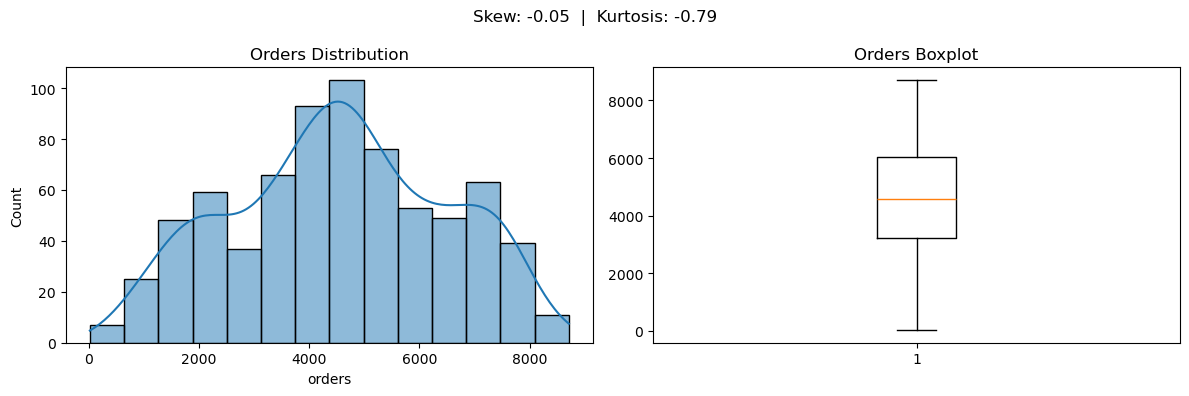

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['orders'], kde=True, ax=ax[0])
ax[0].set_title('Orders Distribution')
ax[1].boxplot(df['orders'])
ax[1].set_title('Orders Boxplot')
plt.suptitle(f"Skew: {df['orders'].skew():.2f}  |  Kurtosis: {df['orders'].kurtosis():.2f}")
plt.tight_layout(); plt.show()

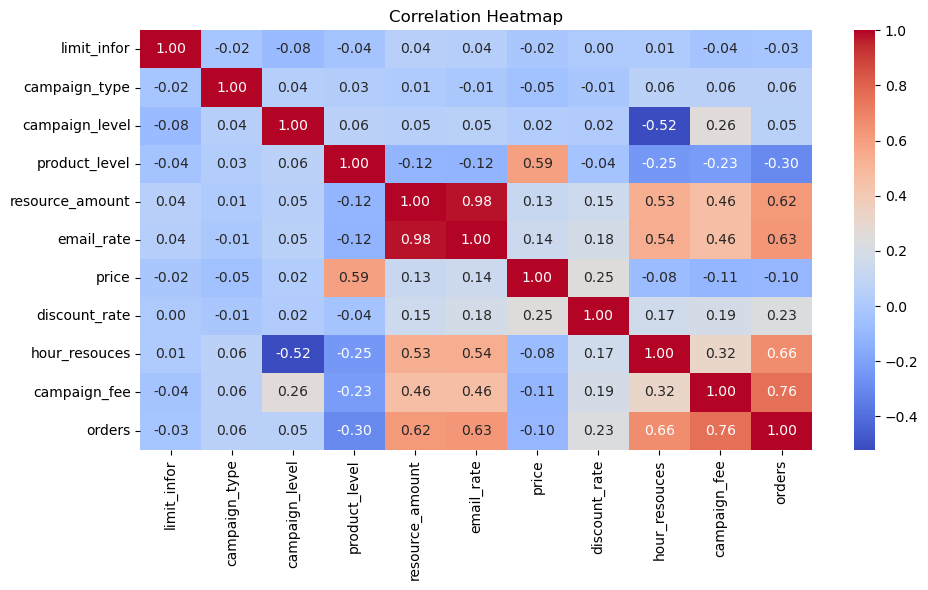

In [8]:
plt.figure(figsize=(10, 6))
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

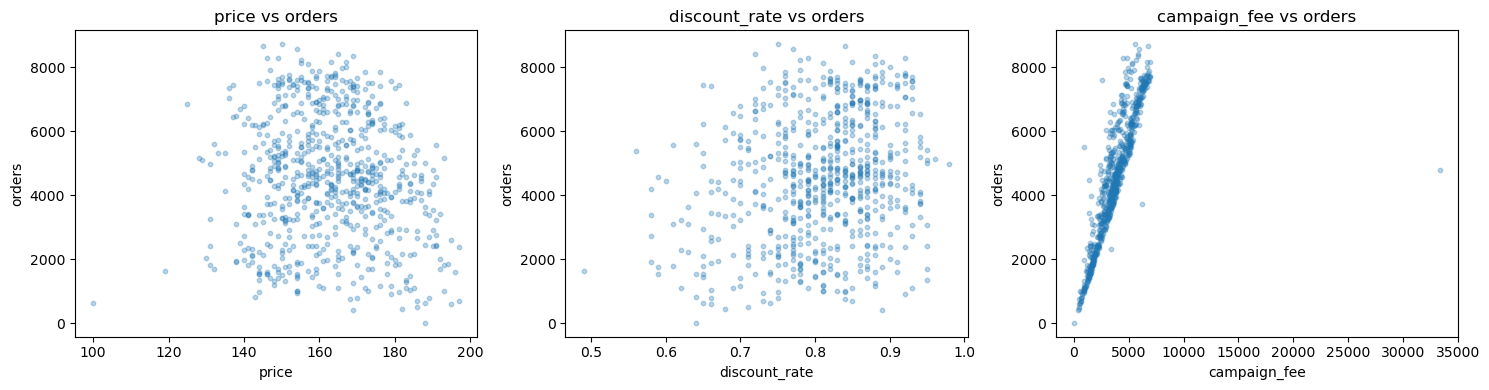

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['price', 'discount_rate', 'campaign_fee']):
    ax.scatter(df[col], df['orders'], alpha=0.3, s=10)
    ax.set_xlabel(col); ax.set_ylabel('orders')
    ax.set_title(f'{col} vs orders')
plt.tight_layout(); plt.show()

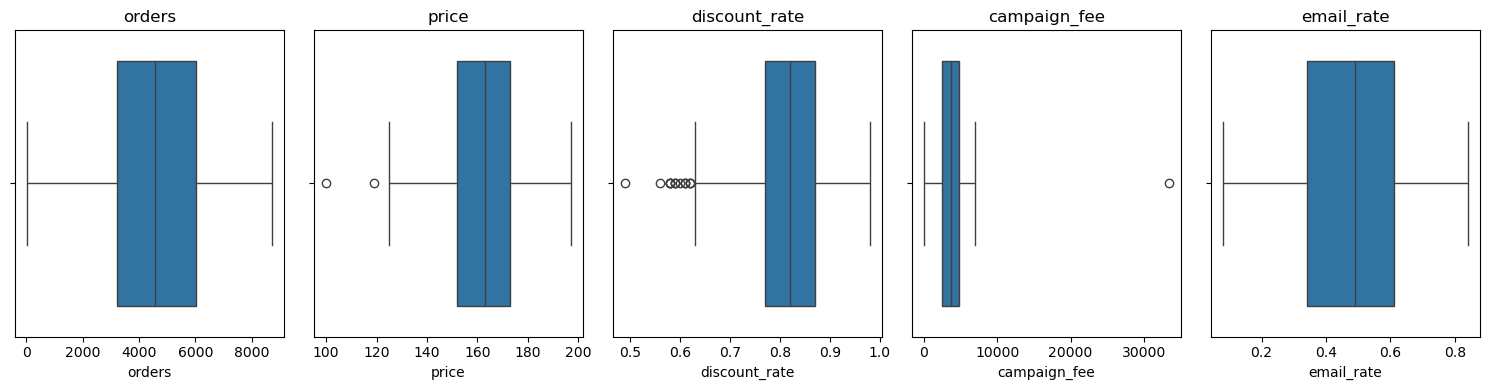

In [10]:
# Boxplot for outlier Detection
cols = ['orders','price','discount_rate','campaign_fee','email_rate']
fig,ax = plt.subplots(1,len(cols),figsize=(15,4))
for i,c in enumerate(cols):
    sns.boxplot(x=df[c],ax=ax[i])
    ax[i].set_title(c)
plt.tight_layout()
plt.show()

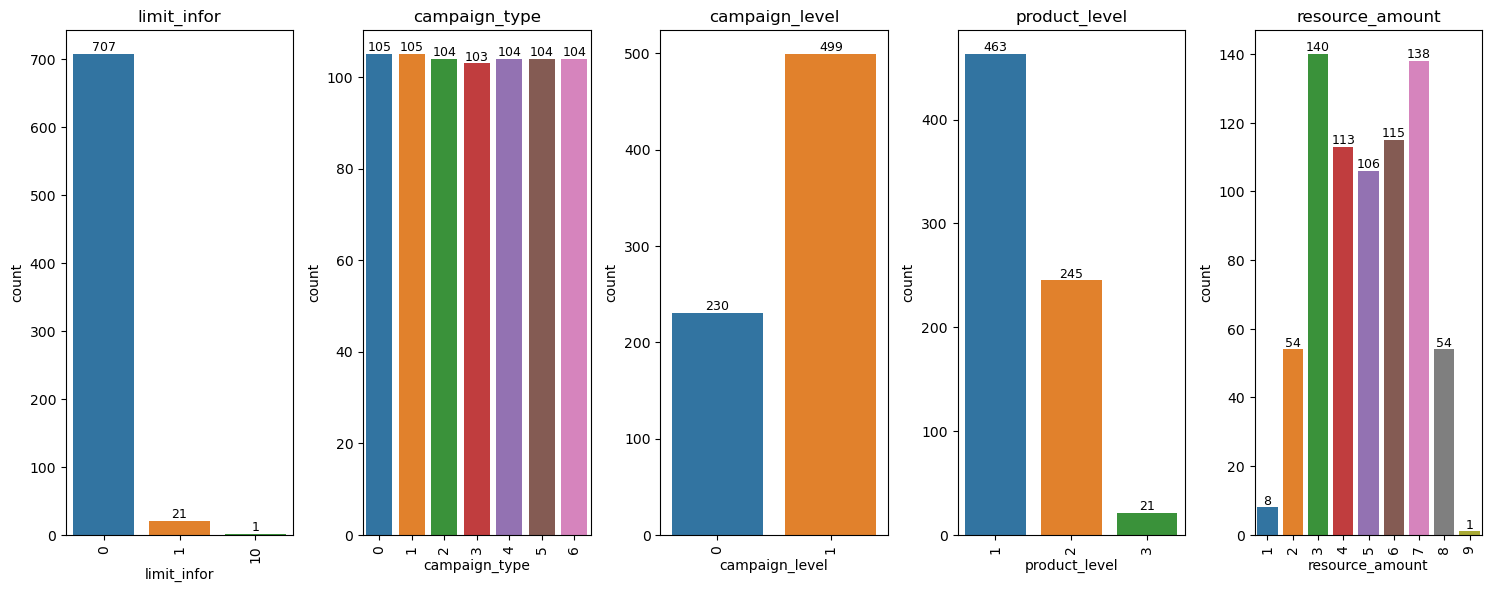

In [11]:
# Categorical Distribution
cat_cols=['limit_infor','campaign_type','campaign_level','product_level','resource_amount']
fig,ax = plt.subplots(1,len(cat_cols),figsize=(15,6))
for a,col in zip(ax.flatten(),cat_cols):
    sns.countplot(data=df,x=col,palette='tab10',ax=a)
    for p in a.patches:
        a.annotate(int(p.get_height()),
                    (p.get_x()+p.get_width()/2.,p.get_height()),
                    ha='center',va='bottom',fontsize=9)
    a.set_title(col)
    a.tick_params(axis='x',rotation=90)
plt.tight_layout(pad=1)
plt.show()

## Step 5: Feature Engineering

In [12]:
# Outlier treatment — clip features, remove extreme target rows
df_clean = df.copy() 
q_lo = df_clean['orders'].quantile(0.01)
q_hi = df_clean['orders'].quantile(0.99)
df_clean['orders'] = df_clean['orders'].clip(q_lo, q_hi)
print(f'Target clipped to [{q_lo:.1f}, {q_hi:.1f}] — all {len(df_clean)} rows retained')

# --- Features: 1-99% clip ---
for col in ['campaign_fee', 'discount_rate', 'price', 'email_rate']:
    lo, hi = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    n_clipped = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lo, hi)
    print(f'  {col}: {n_clipped} values clipped ({n_clipped/len(df_clean)*100:.1f}%)')

print(f'Rows after outlier treatment: {len(df_clean)}  (no rows dropped)')

Target clipped to [689.2, 8210.2] — all 729 rows retained
  campaign_fee: 16 values clipped (2.2%)
  discount_rate: 8 values clipped (1.1%)
  price: 12 values clipped (1.6%)
  email_rate: 16 values clipped (2.2%)
Rows after outlier treatment: 729  (no rows dropped)


In [13]:
# Fix discount scale (0-100 → 0-1)
df_clean['discount_rate'] = np.where(
    df_clean['discount_rate'] > 1,
    df_clean['discount_rate'] / 100,
    df_clean['discount_rate'])
print('discount_rate range:', df_clean['discount_rate'].min(), '-', df_clean['discount_rate'].max())

discount_rate range: 0.59 - 0.95


# Log-transform skewed numeric features
for col in ['campaign_fee', 'price']:
    df_clean[col] = np.log1p(df_clean[col])
print('Log1p applied to campaign_fee and price')
df_clean[['campaign_fee', 'price']].describe()

In [14]:
#  Drop  column with no predictive value
df_model = df_clean.drop(columns=['resource_amount'])
print('Columns before encoding:', df_model.columns.tolist())

Columns before encoding: ['limit_infor', 'campaign_type', 'campaign_level', 'product_level', 'email_rate', 'price', 'discount_rate', 'hour_resouces', 'campaign_fee', 'orders']


In [15]:
#  ONE-HOT ENCODE CATEGORICALS  
encode_cols = ['campaign_type', 'campaign_level', 'product_level', 'limit_infor']
df_model = pd.get_dummies(df_model, columns=encode_cols, drop_first=True)
print('Shape after encoding:', df_model.shape)
print('Dtypes:', df_model.dtypes.value_counts().to_dict())
df_model.head()

Shape after encoding: (729, 17)
Dtypes: {dtype('bool'): 11, dtype('float64'): 5, dtype('int64'): 1}


,email_rate,price,discount_rate,hour_resouces,campaign_fee,orders,campaign_type_1,campaign_type_2,campaign_type_3,campaign_type_4,campaign_type_5,campaign_type_6,campaign_level_1,product_level_2,product_level_3,limit_infor_1,limit_infor_10
0,0.1428,140.0,0.83,93,888.0,1981.0,False,False,False,False,False,True,False,False,False,False,False
1,0.1428,144.0,0.75,150,836.0,986.0,False,False,False,False,False,False,False,False,False,False,False
2,0.1428,149.0,0.84,86,1330.0,1416.0,True,False,False,False,False,False,True,False,False,False,False
3,0.1428,141.0,0.82,95,2273.0,2368.0,False,False,True,False,False,False,True,True,False,False,False
4,0.1428,146.0,0.59,73,1456.0,1529.0,False,False,False,False,False,False,False,False,False,False,False


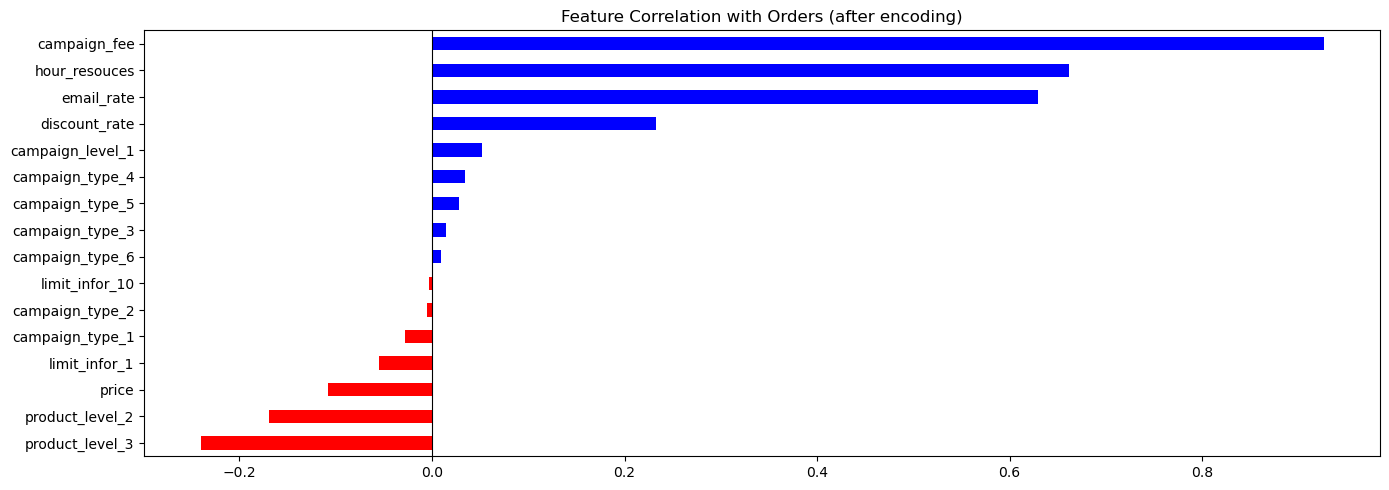

In [16]:
# Post-encoding correlation with target
plt.figure(figsize=(14, 5))
corr = df_model.corr()['orders'].drop('orders').sort_values()
colors = ['red' if v < 0 else 'blue' for v in corr]
corr.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Orders (after encoding)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

## Step 6: Train / Test Split

In [42]:
X = df_model.drop('orders', axis=1)
y = df_model['orders']
# Holdout split — carved out BEFORE any fitting
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X, y, test_size=0.10, random_state=0, shuffle=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=42, shuffle=True)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Target — Train mean: {y_train.mean():.2f}  |  Test mean: {y_test.mean():.2f}')
print(f'Features ({X.shape[1]}):', list(X.columns))

Train: (492, 16)  |  Test: (164, 16)
Target — Train mean: 4601.48  |  Test mean: 4310.39
Features (16): ['email_rate', 'price', 'discount_rate', 'hour_resouces', 'campaign_fee', 'campaign_type_1', 'campaign_type_2', 'campaign_type_3', 'campaign_type_4', 'campaign_type_5', 'campaign_type_6', 'campaign_level_1', 'product_level_2', 'product_level_3', 'limit_infor_1', 'limit_infor_10']


## Step 7: Scaling

In [43]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same params to test
print('Scaling done. Train scaled mean (should be ~0):', round(X_train_sc.mean(), 6))

Scaling done. Train scaled mean (should be ~0): -0.0


## Step 8: Train All 9 Models

In [44]:
# Model registry: (needs_scaling, model_instance)
all_models = {
    'LinearRegression' : (True,  LinearRegression()),
    'Ridge'            : (True,  Ridge(alpha=1.0)),
    'Lasso'            : (True,  Lasso(alpha=0.05)),
    'SVR'              : (True,  SVR(kernel='rbf', C=10, epsilon=0.1)),
    'KNN'              : (True,  KNeighborsRegressor(n_neighbors=7)),
    'RandomForest'     : (False, RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    'GradientBoosting' : (False, GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                            max_depth=5, random_state=42)),
}

results = {}
trained = {}

print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R2':>8}  {'CV-R2':>8}")
print('-' * 62)

for name, (needs_scale, model) in all_models.items():
    Xtr = X_train_sc if needs_scale else X_train.values
    Xte = X_test_sc  if needs_scale else X_test.values

    model.fit(Xtr, y_train)
    y_pred_m = model.predict(Xte)

    mae_m  = mean_absolute_error(y_test, y_pred_m)
    rmse_m = float(np.sqrt(mean_squared_error(y_test, y_pred_m)))
    r2_m   = r2_score(y_test, y_pred_m)
    cv_r2  = cross_val_score(model, Xtr, y_train, cv=5, scoring='r2').mean()

    results[name] = {'MAE': mae_m, 'RMSE': rmse_m, 'R2': r2_m, 'CV_R2': cv_r2}
    trained[name] = (model, needs_scale)
    print(f'{name:<22} {mae_m:>8.3f} {rmse_m:>8.3f} {r2_m:>8.4f}  {cv_r2:>8.4f}')

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print('\nBest model so far:', results_df.index[0])

Model                       MAE     RMSE       R2     CV-R2
--------------------------------------------------------------
LinearRegression        102.309  219.911   0.9893    0.9477
Ridge                   104.486  220.490   0.9893    0.9478
Lasso                   102.280  219.885   0.9893    0.9478
SVR                    1681.219 1975.335   0.1379    0.1117
KNN                     691.088  858.531   0.8371    0.7563
RandomForest            159.591  323.230   0.9769    0.9327
GradientBoosting        169.746  393.341   0.9658    0.9254

Best model so far: Lasso


## Step 9: Model Comparison Visualisation

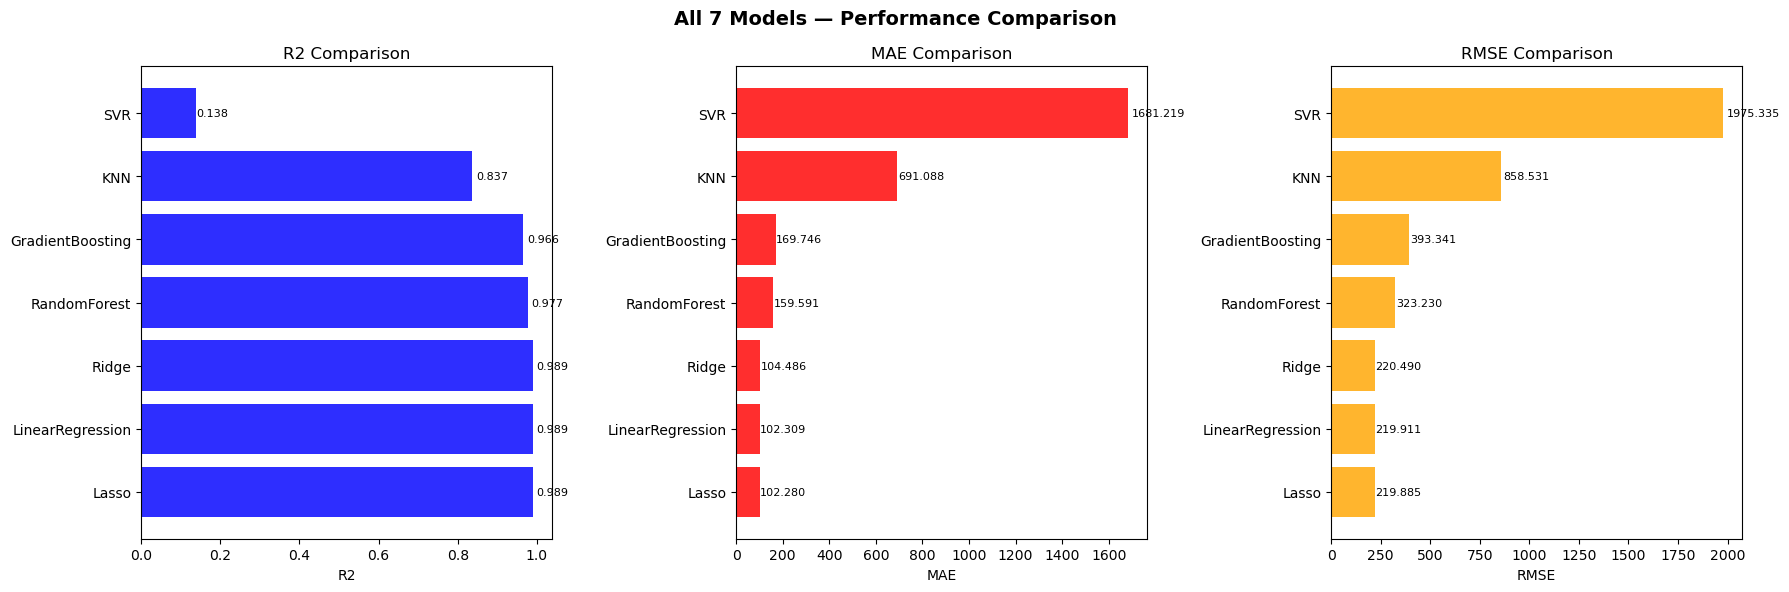

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric, color, asc in zip(axes,
    ['R2', 'MAE', 'RMSE'], ['blue', 'red', 'orange'], [False, True, True]):
    vals = results_df[metric].sort_values(ascending=asc)
    ax.barh(vals.index, vals.values, color=color, alpha=0.82)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlabel(metric)
    for i, v in enumerate(vals.values):
        ax.text(v * 1.01, i, f'{v:.3f}', va='center', fontsize=8)
plt.suptitle('All 7 Models — Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 10: Best Baseline Model — Deep Dive

Best baseline model: Lasso
  R2   : 0.9893
  MAE  : 102.2799
  RMSE : 219.8847


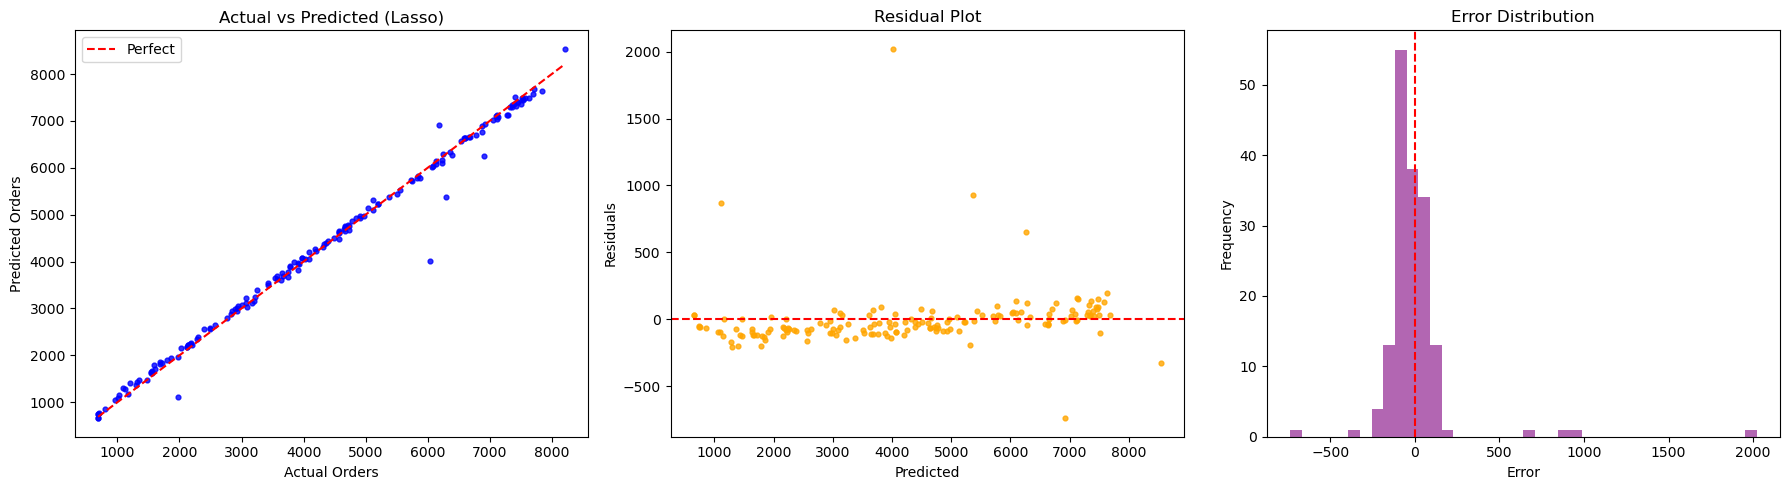

In [45]:
best_name = results_df.index[0]
best_model, best_scaled = trained[best_name]
Xte_best = X_test_sc if best_scaled else X_test.values
y_pred_best = best_model.predict(Xte_best)
residuals   = y_test.values - y_pred_best

print(f'Best baseline model: {best_name}')
print(f'  R2   : {results_df.loc[best_name, "R2"]:.4f}')
print(f'  MAE  : {results_df.loc[best_name, "MAE"]:.4f}')
print(f'  RMSE : {results_df.loc[best_name, "RMSE"]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_test, y_pred_best, alpha=0.8, s=12, color='blue')
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', label='Perfect')
axes[0].set_xlabel('Actual Orders'); axes[0].set_ylabel('Predicted Orders')
axes[0].set_title(f'Actual vs Predicted ({best_name})')
axes[0].legend()
axes[1].scatter(y_pred_best, residuals, alpha=0.8, s=12, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[2].hist(residuals, bins=40, color='purple', alpha=0.6)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Error'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Error Distribution')
plt.tight_layout(); plt.show()

In [46]:
print(trained.keys())
print(results_df.index.tolist())

dict_keys(['LinearRegression', 'Ridge', 'Lasso', 'SVR', 'KNN', 'RandomForest', 'GradientBoosting'])
['Lasso', 'LinearRegression', 'Ridge', 'RandomForest', 'GradientBoosting', 'KNN', 'SVR']


## Step 11: Linear Regularisation Comparison

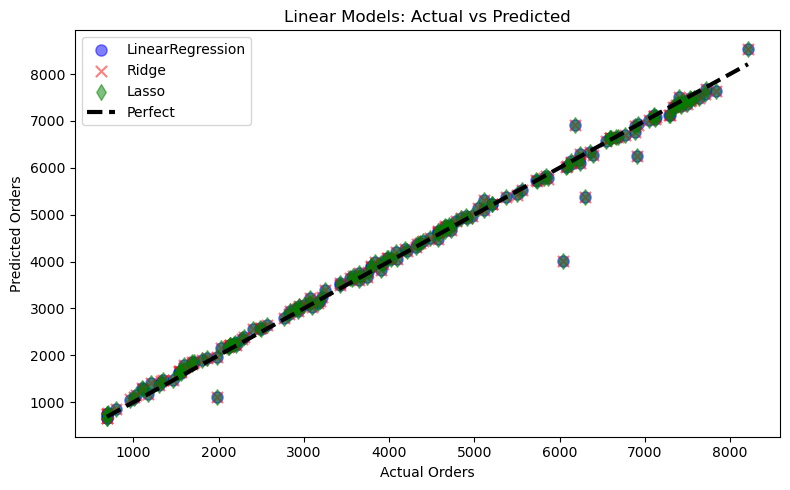

In [23]:
pairs = [
    ('LinearRegression', 'blue',   'o'),
    ('Ridge',            'red',    'x'),
    ('Lasso',            'green', 'd'),
]
plt.figure(figsize=(8, 5))
for name, color, marker in pairs:
    mdl, sc = trained[name]
    preds = mdl.predict(X_test_sc)
    plt.scatter(y_test, preds, alpha=0.5, s=65, label=name, marker=marker, color=color)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, 'k--', label='Perfect', linewidth=3.0)
plt.xlabel('Actual Orders'); plt.ylabel('Predicted Orders')
plt.title('Linear Models: Actual vs Predicted')
plt.legend(); plt.tight_layout(); plt.show()

## Step 12: XGBoost Hyperparameter Tuning (Optuna — 30 Trials)

In [24]:
# XGBoost is a tree model — uses UNSCALED encoded X_train
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 3),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 3),
        'random_state': 42, 'verbosity': 0, 'n_jobs': -1,
    }
    mdl = XGBRegressor(**params)
    return cross_val_score(mdl, X_train, y_train, cv=5, scoring='r2').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print('Best CV R2:', round(study.best_value, 4))
print('Best Params:', study.best_params)

Best CV R2: 0.9409
Best Params: {'n_estimators': 147, 'max_depth': 9, 'learning_rate': 0.04445615220974266, 'subsample': 0.645521469902462, 'colsample_bytree': 0.9354508030933985, 'min_child_weight': 8, 'reg_alpha': 2.9867014984417333, 'reg_lambda': 2.4322181954965107}


In [25]:
model_xgb = XGBRegressor(**study.best_params, verbosity=0, n_jobs=-1)
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb = model_xgb.predict(X_test)   # fresh variable — not reused from elsewhere

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = float(np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f'XGBoost (Optuna-tuned):')
print(f'  MAE  : {mae_xgb:.4f}')
print(f'  RMSE : {rmse_xgb:.4f}')
print(f'  R2   : {r2_xgb:.4f}')

results['XGBoost_Optuna'] = {'MAE': mae_xgb, 'RMSE': rmse_xgb,
                              'R2': r2_xgb, 'CV_R2': study.best_value}
results_df2 = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print('\nFinal Leaderboard:')
print(results_df2[['R2','MAE','RMSE','CV_R2']].to_string())

XGBoost (Optuna-tuned):
  MAE  : 155.7304
  RMSE : 282.1108
  R2   : 0.9824

Final Leaderboard:
                        R2          MAE         RMSE     CV_R2
Lasso             0.989318   102.279896   219.884702  0.947755
LinearRegression  0.989315   102.309158   219.911394  0.947747
Ridge             0.989259   104.486323   220.490451  0.947767
XGBoost_Optuna    0.982416   155.730387   282.110751  0.940879
RandomForest      0.976916   159.591138   323.230006  0.932713
GradientBoosting  0.965816   169.745901   393.340859  0.925434
KNN               0.837149   691.087875   858.530899  0.756340
SVR               0.137894  1681.218947  1975.335187  0.111745


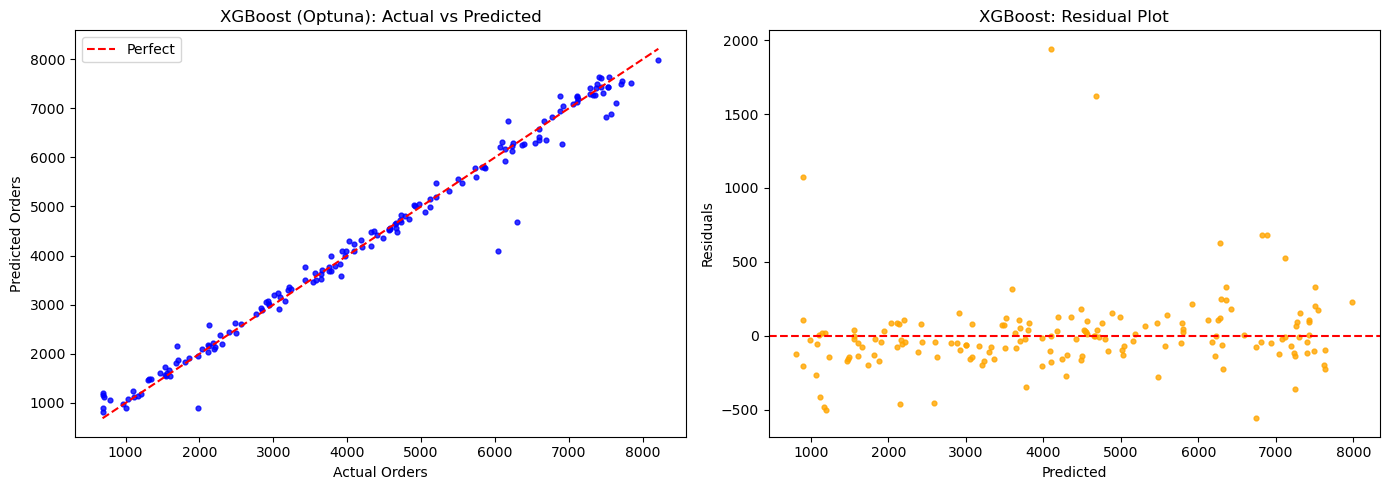

In [26]:
# XGBoost (Optuna): Actual vs Predicted and XGBoost: Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_xgb, alpha=0.8, s=12, color='blue')
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--', label='Perfect')
axes[0].set_xlabel('Actual Orders'); axes[0].set_ylabel('Predicted Orders')
axes[0].set_title('XGBoost (Optuna): Actual vs Predicted'); axes[0].legend()
residuals_xgb = y_test.values - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.8, s=12, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost: Residual Plot')
plt.tight_layout(); plt.show()

## Step 13: Feature Importance (XGBoost + RandomForest)

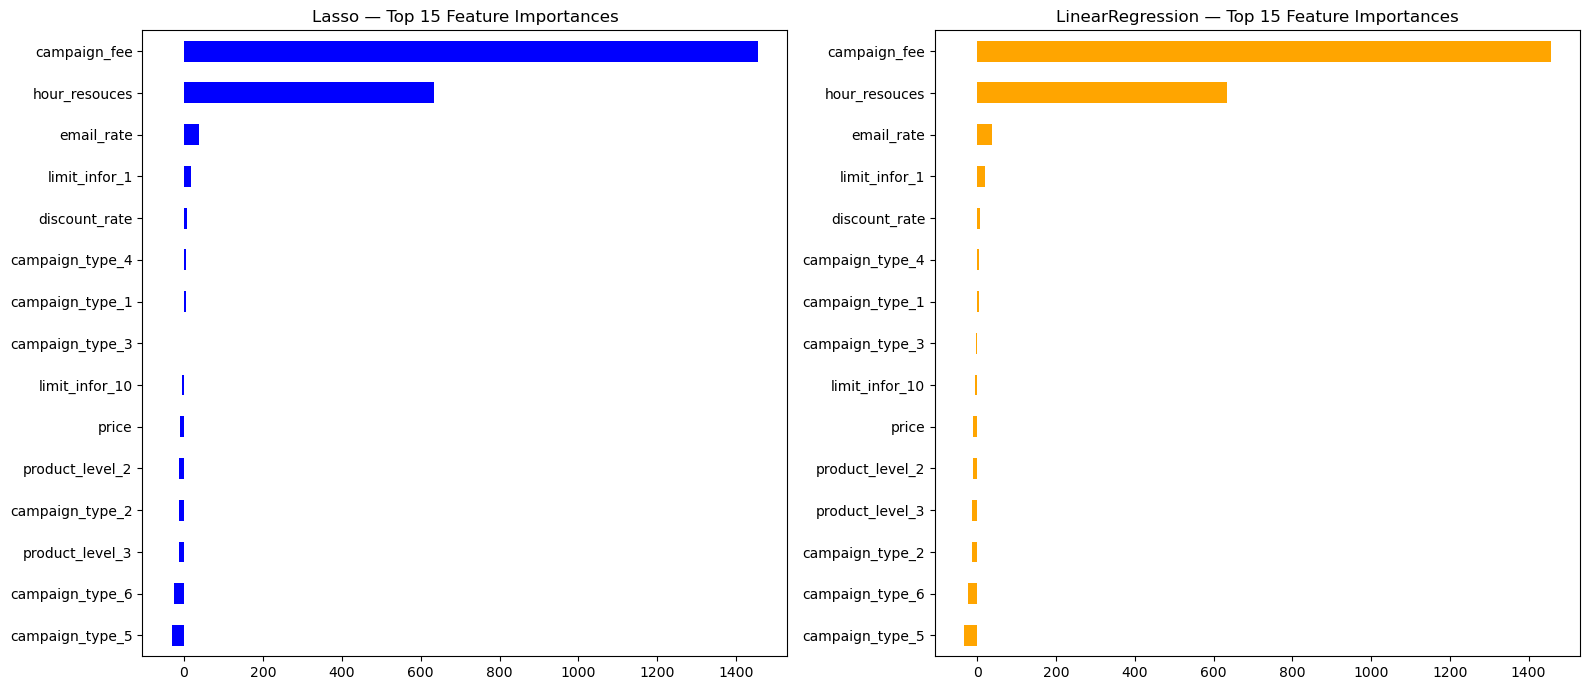

In [51]:
fi_ls = pd.Series(best_model.coef_, index=X.columns).sort_values(ascending=True)
lg_model = trained['LinearRegression'][0]
fi_lg = pd.Series(ls_model.coef_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fi_ls.tail(15).plot(kind='barh', ax=axes[0], color='blue')
axes[0].set_title('Lasso — Top 15 Feature Importances')
fi_lg.tail(15).plot(kind='barh', ax=axes[1], color='orange')
axes[1].set_title('LinearRegression — Top 15 Feature Importances')
plt.tight_layout(); plt.show()

## Step 14: SHAP Explainability

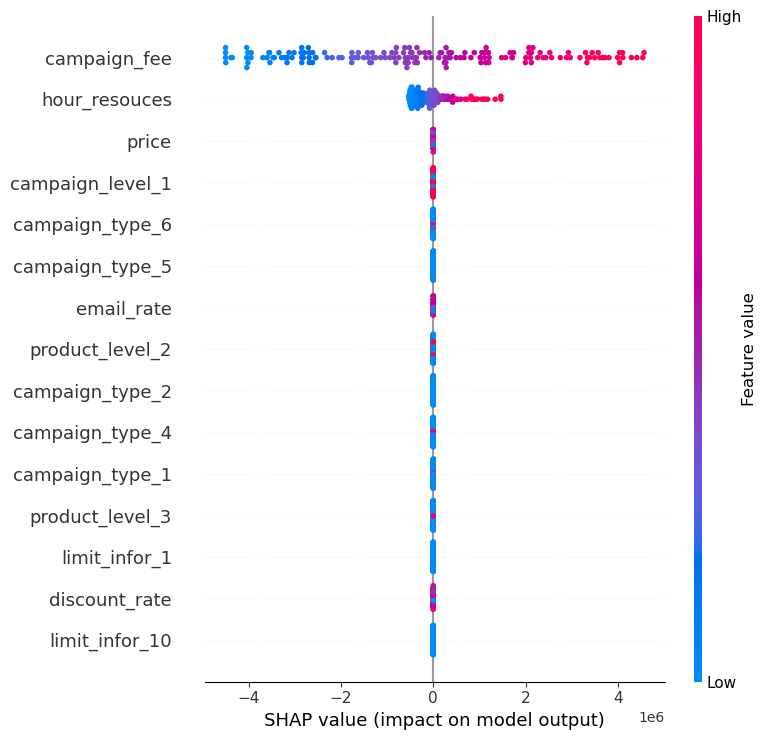

In [63]:
# shap for feature
X_train_arr = np.array(X_train, dtype=float)
X_test_arr  = np.array(X_test,  dtype=float)
explainer   = shap.LinearExplainer(best_model, X_train_arr)
shap_values = np.array(explainer.shap_values(X_test_arr))
shap.summary_plot(shap_values,X_test_arr,feature_names=list(X_test.columns),max_display=15)

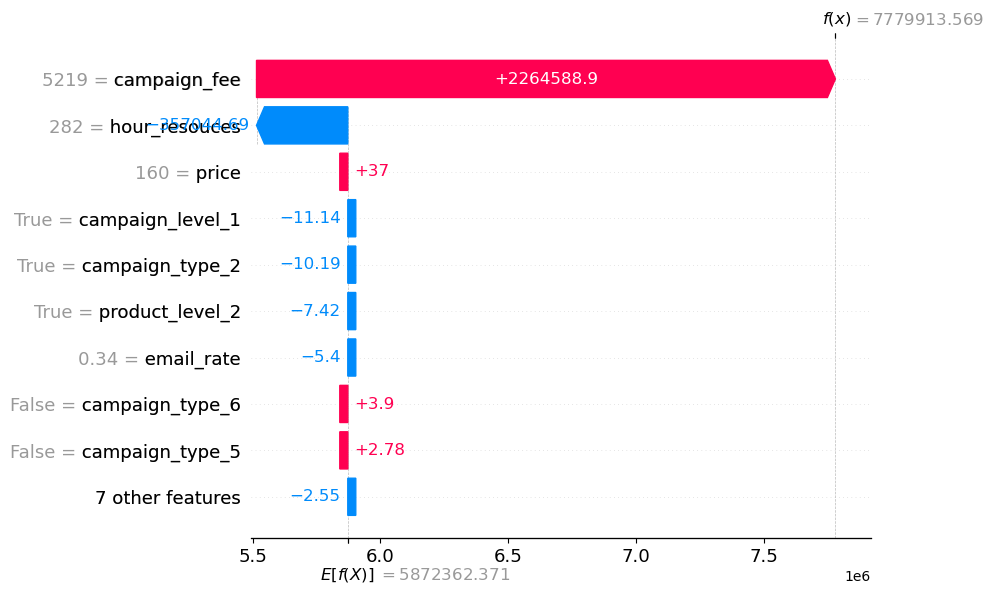

In [64]:
shap_exp = explainer(X_test)
shap.plots.waterfall(shap_exp[0])

In [65]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

## Step 15: Final Leaderboard

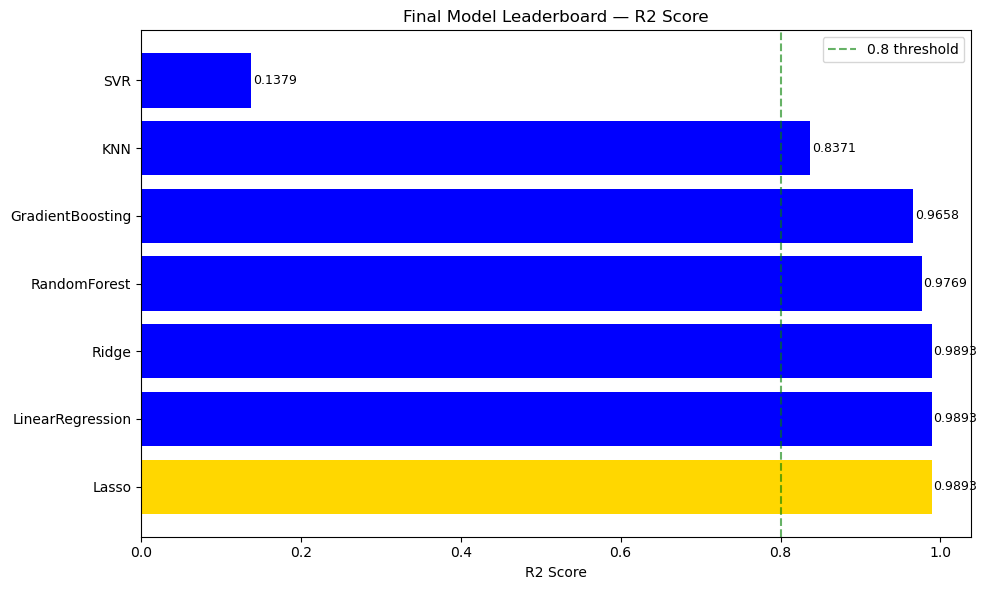

                        R2          MAE         RMSE     CV_R2
Lasso             0.989318   102.279896   219.884702  0.947755
LinearRegression  0.989315   102.309158   219.911394  0.947747
Ridge             0.989259   104.486323   220.490451  0.947767
RandomForest      0.976916   159.591138   323.230006  0.932713
GradientBoosting  0.965816   169.745901   393.340859  0.925434
KNN               0.837149   691.087875   858.530899  0.756340
SVR               0.137894  1681.218947  1975.335187  0.111745


In [66]:
final_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['gold'] + ['blue'] * (len(final_df)-1)
bars = ax.barh(final_df.index, final_df['R2'], color=bar_colors)
ax.set_xlabel('R2 Score')
ax.set_title('Final Model Leaderboard — R2 Score')
ax.axvline(0.8, color='green', linestyle='--', alpha=0.6, label='0.8 threshold')
for bar, val in zip(bars, final_df['R2']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print(final_df[['R2','MAE','RMSE','CV_R2']].to_string())

── Holdout Set (never seen during training) ──
  R²   : 0.9590
  MAE  : 162.6486
  RMSE : 365.0353

── Test Set (used for model selection) ──
  R²   : 0.9824
  MAE  : 155.7304
  RMSE : 282.1108

Generalization gap: 0.0234 — ACCEPTABLE (minor overfitting)


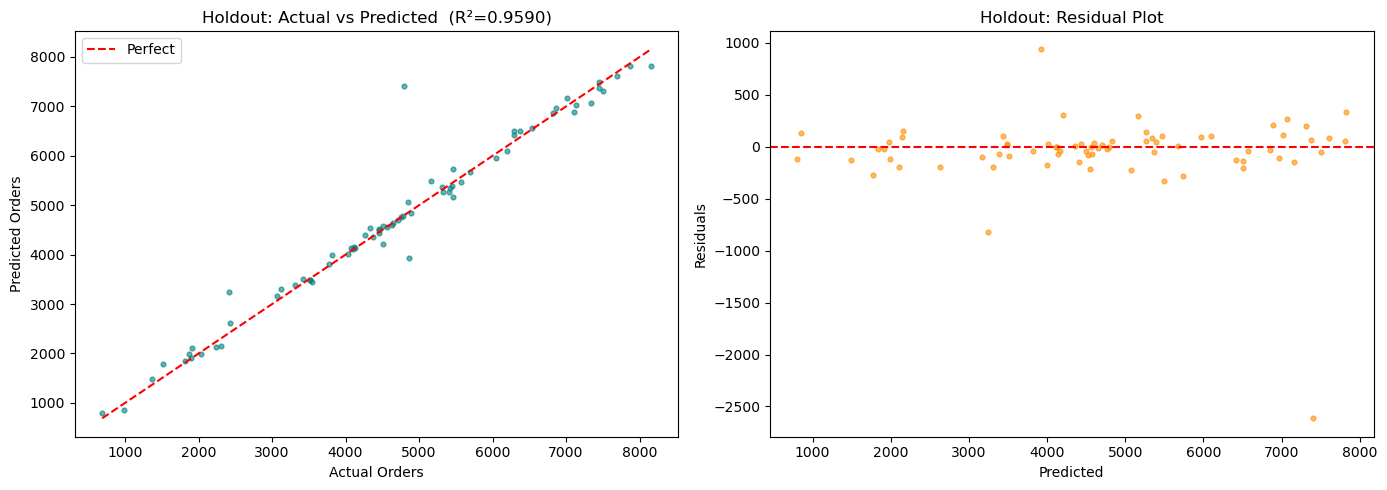

In [67]:
# Holdout evaluation — unbiased generalization estimate
y_pred_holdout = model_xgb.predict(X_holdout)
mae_h  = mean_absolute_error(y_holdout, y_pred_holdout)
rmse_h = float(np.sqrt(mean_squared_error(y_holdout, y_pred_holdout)))
r2_h   = r2_score(y_holdout, y_pred_holdout)

print('── Holdout Set (never seen during training) ──')
print(f'  R²   : {r2_h:.4f}')
print(f'  MAE  : {mae_h:.4f}')
print(f'  RMSE : {rmse_h:.4f}')
print()
print('── Test Set (used for model selection) ──')
print(f'  R²   : {r2_xgb:.4f}')
print(f'  MAE  : {mae_xgb:.4f}')
print(f'  RMSE : {rmse_xgb:.4f}')
print()
gap = abs(r2_xgb - r2_h)
if gap < 0.02:
    print(f'Generalization gap (|test R² - holdout R²|): {gap:.4f} — GOOD (model generalizes well)')
elif gap < 0.05:
    print(f'Generalization gap: {gap:.4f} — ACCEPTABLE (minor overfitting)')
else:
    print(f'Generalization gap: {gap:.4f} — WARNING: possible overfitting; consider stronger regularization')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_holdout, y_pred_holdout, alpha=0.6, s=12, color='teal')
lim = [y_holdout.min(), y_holdout.max()]
axes[0].plot(lim, lim, 'r--', label='Perfect')
axes[0].set_xlabel('Actual Orders'); axes[0].set_ylabel('Predicted Orders')
axes[0].set_title(f'Holdout: Actual vs Predicted  (R²={r2_h:.4f})')
axes[0].legend()
residuals_h = y_holdout.values - y_pred_holdout
axes[1].scatter(y_pred_holdout, residuals_h, alpha=0.6, s=12, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Holdout: Residual Plot')
plt.tight_layout(); plt.show()

## Step 16: Save Models

In [68]:
import joblib, pickle

joblib.dump(model_xgb, 'model_xgb.pkl')
joblib.dump(scaler,    'scaler.pkl')
pickle.dump(list(X.columns), open('columns.pkl', 'wb'))

print('Saved: model_xgb.pkl, scaler.pkl, columns.pkl')
print('Expected inference columns:', list(X.columns))

Saved: model_xgb.pkl, scaler.pkl, columns.pkl
Expected inference columns: ['email_rate', 'price', 'discount_rate', 'hour_resouces', 'campaign_fee', 'campaign_type_1', 'campaign_type_2', 'campaign_type_3', 'campaign_type_4', 'campaign_type_5', 'campaign_type_6', 'campaign_level_1', 'product_level_2', 'product_level_3', 'limit_infor_1', 'limit_infor_10']


## Step 17: Streamlit App 

In [69]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib, pickle

model   = joblib.load('model_xgb.pkl')
columns = pickle.load(open('columns.pkl', 'rb'))
scaler  = joblib.load('scaler.pkl')
st.title('Campaign Orders Prediction')
st.markdown('Fill in campaign details to predict **orders**.')

with st.form('pred_form'):
    c1, c2 = st.columns(2)
    with c1:
        email_rate     = st.number_input('Email Rate (0-1.00)',    0.08,0.84,0.30)
        campaign_fee   = st.number_input('Campaign Fee',        0.0, value=5000.0)
        price          = st.number_input('Price',               0.0, value=999.0)
        discount_rate  = st.number_input('Discount Rate (0-1.00)',0.49, 0.98,0.60)
    with c2:
        campaign_type  = st.selectbox('Campaign Type',   ['A','B','C','D','E','F'])
        campaign_level = st.selectbox('Campaign Level',  ['1','2'])
        product_level  = st.selectbox('Product Level',   ['low','mid','high'])
        resource_amount= st.selectbox('Resource Amount', ['small','medium','large'])
    submitted = st.form_submit_button('Predict Orders')

if submitted:
    raw = {'email_rate'     : email_rate,
           'campaign_fee'   : np.log1p(campaign_fee),
           'price'          : np.log1p(price),
           'discount_rate'  : discount_rate,
           'campaign_type'  : campaign_type,
           'campaign_level' : campaign_level,
           'product_level'  : product_level,
           'resource_amount': resource_amount}
    inp = pd.DataFrame([raw])
    inp = pd.get_dummies(inp)
    inp = inp.reindex(columns=columns, fill_value=0)
    pred = model.predict(inp.values)[0]
    st.success(f'Predicted Orders: {pred:.0f}')
'''
with open('app.py', 'w') as f:
    f.write(app_code)
print('app.py saved. Run: streamlit run app.py')

app.py saved. Run: streamlit run app.py
